# RNN / LSTM on timeseries forecasting

Idée c'est de prendre le dataset electricity load diagrams et d'applique des modèles récurent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

from tsai.all import LSTM, TST, RNN, TSTPlus
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error

# check si gpu dispo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


### Chargement données

In [2]:
data = pd.read_csv("usefull_dataset.csv", delimiter=',', lineterminator='\n')
data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])  #convertit 1er colone en data
data.set_index('Unnamed: 0', inplace=True)  # met cette colonne comme index

print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 140256 entries, 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   MT_292  140256 non-null  float64
dtypes: float64(1)
memory usage: 2.1 MB
None


### Pré traitement

Pour entrainer le modèle on va pas juste lui donner une chaine de 100k+ element et prédire 1, ce qu'on va faire c'est lui donner 1 semaine de data donc 672 point et on va lui demander de génére 96 points pour générer la jounrée d'après pour faire du short term.

Utilise toujours les 3 set, mets va les traiter pour le mettre dans la même forme que train donc 1 semaine et forecast la journée d'après.

On va ensuite créer un dataset qui sera genre :
- 96 valeur à prédire
- 672 valeur passé

tout ça organisé du dernière au premier donc plus récent au début pour pytorch.

Pour faire ça le fait dans un dataset pytorch ou par pandas. Ici je vai

In [3]:
#BASE PARAMETER
PAST_WINDOW = 672  #regarde 1 semaine en arrière 96*7
FUTURE_WINDOW = 96  #prédit 1 jour à l'avance


#split : 
index_list = data.index.tolist()

train_limit = int(len(data) * 0.8) #prend 80% longueur data pour train et prend le début sinon prendre la fin ne fait pas de sens pour prédire ce qui avant car c'est pas ce qu'on veut
train_data = data[:train_limit]

MAE_NAIVE = mean_absolute_error(train_data['MT_292'][1:], train_data['MT_292'].shift(1).dropna())

validation_limit = int(len(data) * 0.9) #prend un peu de validation aussi
validation_data = data[train_limit:validation_limit]

test_data = data[validation_limit:] #et le reste en ensemble de test


# tmp = train_data['MT_292'].values
# print(tmp)
# MAE_NAIVE = tmp[1:]-tmp[:-1]
# MAE_NAIVE = np.abs(MAE_NAIVE).mean() #calcule à l'avance pour utilsier autre part

#scale les données
scaler = MinMaxScaler() #stocke bien les paramètres de scaling pour plus tard faire l'inverse et voir les vrai valeur pour quand on voudra plot
train_data_scaled = scaler.fit_transform(train_data) #fit transform pour tout mettre en -1 et 1 et éviter effet d'échelle
validation_data_scaled = scaler.transform(validation_data) #ne refit pas utilise les même paramètres donc pourrait avoir plus que 1 ou moins que -1 mais pas grave
test_data_scaled = scaler.transform(test_data) #same


def make_windows(series, input_len=PAST_WINDOW, output_len=FUTURE_WINDOW):
    series = np.asarray(series).reshape(-1) #force à avoir que 1 dimension et pas dim x 1 et pète tout
    X, y = [], []
    for i in range(len(series) - input_len - output_len):
        X.append(series[i:i+input_len])
        y.append(series[i+input_len:i+input_len+output_len])
    X = np.array(X)[:, None, :]   # mets torch.tensor(train_data_scaled, dtype=torch.float32)) #passe tout en torch tensor pour que pytorch puisse l'utiliserdans forma sample, feature, time step
    y = np.array(y)
    return X, y


class LoadDataset(torch.utils.data.Dataset): #classe pour faire le dataset
    def __init__(self, X, y): 
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self): 
        return len(self.X)

    def __getitem__(self, idx): #pour récuprer un élément
        return self.X[idx], self.y[idx]


In [4]:
BATCH_SIZE = 32

X_train, y_train = make_windows(train_data_scaled)
X_val, y_val = make_windows(validation_data_scaled)
X_test, y_test = make_windows(test_data_scaled)

print(X_train.shape, y_train.shape)

#créer les dataset
train_dataset = LoadDataset(X_train, y_train)
validation_dataset = LoadDataset(X_val, y_val)
test_dataset = LoadDataset(X_test, y_test)

#créer les dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) #le shuffle pour arrive à que utilisé la window past pour prédire le future
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False) #test en suivant le temps ce coup ci
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

len(train_loader)*BATCH_SIZE, len(validation_loader)*BATCH_SIZE, len(test_loader)*BATCH_SIZE



(111436, 1, 672) (111436, 96)


(111456, 13280, 13280)

### Boucle de train

In [45]:
def smape(y_true, y_pred, eps=1e-8): #définit erreur smape
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)).item() #applique définition smape

def train_model(model, train_loader, val_loader, num_epochs=50, lr=0.0005, model_name='model', save_best=True, device=device):
    # criterion = nn.MSELoss()  # utilise loss MSE car quand a plot semblait pas avoir de gross outlier si y a passera sur L1 plus tard si besoin
    criterion = nn.L1Loss()
    model.to(device) #passe le modèle sur le device
    optimizer = optim.Adam(model.parameters(), lr=lr) #utilise Adam optimizer

    #init tous les loss pour après ainsi retur
    train_losses, val_losses = [], []
    train_maes, val_maes = [], []
    train_mases, val_mases = [], []
    train_smapes, val_smapes = [], []


    #init aussi pour tocker le meilleur
    best_val_loss = float('inf')
    best_model_state = None
    model_path = f'{model_name}.pth'

    for epoch in range(num_epochs): #train
        model.train() #met en mode train
        train_loss, train_mae, train_smape = 0.0, 0.0, 0.0

        all_preds = []
        all_targs = []

        for batch_X, batch_y in train_loader: #fait pour le chaque batch dans le train loader
            batch_X = batch_X.to(device) #mets sur le device fait pas ça à l'avance car sinon perd interêt du batch càd diminuer la mémoire utilisée
            batch_y = batch_y.to(device)

            optimizer.zero_grad() #remet à zero les gradients
            outputs = model(batch_X) #passe le batch dans le modèle

            loss = criterion(outputs, batch_y) #calcule la loss
            loss.backward() #backprop
            optimizer.step() #met à jour les poids

            train_loss += loss.item() #ajoute la loss du batch à la loss totale

            preds = outputs.reshape(-1, 1)
            targs = batch_y.reshape(-1, 1)

            preds_inv = scaler.inverse_transform(preds.cpu().detach().numpy()).reshape(-1, 1)
            targs_inv = scaler.inverse_transform(targs.cpu().detach().numpy()).reshape(-1, 1)

            all_preds.append(preds_inv)
            all_targs.append(targs_inv)

        all_preds = np.concatenate(all_preds, axis=0)
        all_targs = np.concatenate(all_targs, axis=0)

        train_mae = np.mean(np.abs(all_preds - all_targs))
        train_smape = smape(all_targs, all_preds)
        train_mase = train_mae / MAE_NAIVE
        train_loss /= len(train_loader)


        # fait validation
        model.eval() #met en mode évaluation
        val_loss, val_mae, val_smape = 0.0, 0.0, 0.0

        with torch.no_grad(): #pas besoin de calculer les gradients pour la validation
            all_preds = []
            all_targs = []
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)

                outputs = model(batch_X) #passe le batch dans le modèle
                val_loss += criterion(outputs, batch_y).item() #calcule la loss

                #pour calculer les autres métriques faut faire scaller inverse
                preds = outputs.reshape(-1, 1)
                targs = batch_y.reshape(-1, 1)

                preds_inv = scaler.inverse_transform(preds.cpu().detach().numpy()).reshape(-1, 1)
                targs_inv = scaler.inverse_transform(targs.cpu().detach().numpy()).reshape(-1, 1)
                all_preds.append(preds_inv) #stock tous ceux d'ont va utiliser pour calculer les métrique doit pas être fou niveau fitesse et mémoire mais fonctionne et ainsi donnera même résultat que l'autre
                all_targs.append(targs_inv)

        all_preds = np.concatenate(all_preds, axis=0)
        all_targs = np.concatenate(all_targs, axis=0)
        val_mae = np.mean(np.abs(all_preds - all_targs))
        val_smape = smape(all_targs, all_preds)
        val_mase = val_mae / MAE_NAIVE
        val_loss /= len(val_loader)
        

        # sauvegrade le meilleur modèle
        if save_best and val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, model_path)

        # affiche les stats
        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train MAE: {train_mae:.4f} | "
            f"Train SMAPE: {train_smape:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val MAE: {val_mae:.4f} | "
            f"Val SMAPE: {val_smape:.4f} | "
            f"Val MASE: {val_mase:.4f}"
        )

        train_losses.append(train_loss) #ajoute la loss d'entraînement
        val_losses.append(val_loss)
        train_maes.append(train_mae)
        val_maes.append(val_mae)
        train_smapes.append(train_smape)
        val_smapes.append(val_smape)
        train_mases.append(train_mase)
        val_mases.append(val_mase)

    if save_best and best_model_state is not None: #reload le meilleur modèle à la fin
        model.load_state_dict(torch.load(model_path))
        print(f"Best model loaded from {model_path}")

    #return les différentes métriques
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_maes': train_maes,
        'val_maes': val_maes,
        'train_smapes': train_smapes,
        'val_smapes': val_smapes,
        'train_mases': train_mases,
        'val_mases': val_mases,
    }

def print_curves(metrics):
    epochs = range(1, len(metrics['train_losses']) + 1)

    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(epochs, metrics['train_losses'], label='Train Loss')
    plt.plot(epochs, metrics['val_losses'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(epochs, metrics['train_maes'], label='Train MAE')
    plt.plot(epochs, metrics['val_maes'], label='Validation MAE')
    plt.title('MAE over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(epochs, metrics['train_smapes'], label='Train SMAPE')
    plt.plot(epochs, metrics['val_smapes'], label='Validation SMAPE')
    plt.title('SMAPE over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('SMAPE')
    plt.legend()

    plt.tight_layout()
    plt.show()

def test_model(model, test_loader, device=device, best=True, limit=False):
    model.to(device)
    model.eval()
    test_mae, test_smape, test_mase, test_mae_naif = 0.0, 0.0, 0.0, 0.0

    all_preds = []
    all_targs = []

    c = 0

    with torch.no_grad():
        all_preds = []
        all_targs = []
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)

            # print(outputs.shape, batch_y.shape)
            for i in range(outputs.shape[0]): #fait pour chaque élément du batch peut pas le faire d'un coup car scaler besoin de 2D
                
                preds = outputs[i,:].reshape(-1, 1)
                targs = batch_y[i,:].reshape(-1, 1)

                preds_inv = scaler.inverse_transform(preds.cpu().detach().numpy()).reshape(-1, 1)
                targs_inv = scaler.inverse_transform(targs.cpu().detach().numpy()).reshape(-1, 1)

                if best: # si regarde le best càd les premier parmis tous ceux qui ont été prédit
                    all_preds.append(preds_inv[0]) #stock les predictions et target pour après calculer les métriques avec vrai formule
                    all_targs.append(targs_inv[0])
                   
                elif not best and c % FUTURE_WINDOW == 0:
                    all_preds.append(preds_inv)
                    all_targs.append(targs_inv)
                    c=0
                c+=1


    all_preds = np.vstack(all_preds)
    all_targs = np.vstack(all_targs)
    test_mae = np.mean(np.abs(all_preds - all_targs))
    test_smape = smape(all_targs, all_preds)
    test_mase = test_mae / MAE_NAIVE

    print(f"Test MAE: {test_mae:.4f} | Test SMAPE: {test_smape:.4f} | Test MASE: {test_mase:.4f}")

    cut = limit*FUTURE_WINDOW  if limit > 0 else len(all_preds)

    plt.figure(figsize=(12, 6))
    plt.plot(all_targs[:cut], label='True Values')
    plt.plot(all_preds[:cut], label='Predictions')
    plt.title('True vs Predicted Values on Test Set')
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.show()
    return test_mae, test_smape, test_mase

def long_term_forecast(model, val_data_scaled,test_data_scaled, device=device, limit = 0):
    model.to(device)
    model.eval()

    current_window = val_data_scaled[-PAST_WINDOW:].reshape(1, 1, -1)  # commence avec la dernière fenêtre de validation

    with torch.no_grad():
        predictions = []
        for _ in range(len(test_data_scaled) // FUTURE_WINDOW):  # prédit pour toute la période de test
            input_tensor = torch.tensor(current_window, dtype=torch.float32).to(device)
            output = model(input_tensor)
            next_value = output.cpu().numpy().reshape(-1)  # obtenir les prédiction

            predictions.append(next_value)

            # Met à jour la fenêtre courante en ajoutant la nouvelle prédiction et en supprimant les anciennes valeurs
            current_window = np.roll(current_window, -FUTURE_WINDOW)
            current_window[0, 0, -FUTURE_WINDOW:] = next_value  # ajoute la nouvelle prédiction à la fin
        
    #inver scaller
    predictions = np.array(predictions).reshape(-1, 1)
    predictions_inv = scaler.inverse_transform(predictions)

    test_data_inv = scaler.inverse_transform(test_data_scaled)

    cut = limit*FUTURE_WINDOW  if limit > 0 else len(predictions_inv)

    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(test_data_inv[:cut]))/96,test_data_inv[:cut], label='True Values')
    plt.plot(np.arange(len(predictions_inv[:cut]))/96, predictions_inv[:cut], label='Long-term Predictions')
    plt.title('Evolution of Long-term Forecast vs True Values')
    plt.xlabel('Days')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    return predictions_inv.reshape(-1)

def long_term_metric(predictions, test_set, show_plot=True, save_name=None):
    """
        predictions: array of predicted values
        test_set: array of actual values
    """

    metric_place = [96, 672, 1440, 2688, len(predictions)]  # 1 day, 7 days, 15 days 1 month, all

    maes = []
    mases = []
    smapes = []

    for i, place in enumerate(metric_place):
        pred_cut = predictions[:place]
        test_cut = test_set[:place]
        mae = mean_absolute_error(test_cut, pred_cut)
        mase = mae / MAE_NAIVE
        smape = (2 * abs(np.array(pred_cut) - np.array(test_cut)) / (abs(np.array(pred_cut)) + abs(np.array(test_cut)) + 1e-8)).mean()
        maes.append(mae)
        mases.append(mase)
        smapes.append(smape)

    if save_name is not None:
        with open(save_name, 'w') as f:
            f.write("Horizon,MAE,MASE,SMAPE\n")
            for i, place in enumerate(metric_place):
                f.write(f"{place},{maes[i]},{mases[i]},{smapes[i]}\n")

    if not show_plot:
        return maes, mases, smapes
    fig, axs = plt.subplots(3, 1, figsize=(15, 18))

    axs[0].plot(metric_place, maes, label='MAE', marker='o', color='blue')
    axs[0].set_xticks(metric_place)
    axs[0].set_xticklabels(['1 day', '7 days', '15 days', '1 month', 'All'])
    axs[0].set_xlabel('Forecast Horizon')
    axs[0].set_ylabel('MAE')
    axs[0].set_title('MAE over Different Forecast Horizons')
    axs[0].legend()
    axs[0].grid()

    axs[1].plot(metric_place, mases, label='MASE', marker='v', color='green')
    axs[1].set_xticks(metric_place)
    axs[1].set_xticklabels(['1 day', '7 days', '15 days', '1 month', 'All'])
    axs[1].set_xlabel('Forecast Horizon')
    axs[1].set_ylabel('MASE')
    axs[1].set_title('MASE over Different Forecast Horizons')
    axs[1].legend()
    axs[1].grid()

    axs[2].plot(metric_place, smapes, label='SMAPE', marker='s', color='red')
    axs[2].set_xticks(metric_place)
    axs[2].set_xticklabels(['1 day', '7 days', '15 days', '1 month', 'All'])
    axs[2].set_xlabel('Forecast Horizon')
    axs[2].set_ylabel('SMAPE')
    axs[2].set_title('SMAPE over Different Forecast Horizons')
    axs[2].legend()
    axs[2].grid()

    plt.tight_layout()
    plt.show()

### LSTM

LSTM(
  (rnn): LSTM(1, 64, batch_first=True)
  (dropout): Identity()
  (fc): Linear(in_features=64, out_features=96, bias=True)
)
  Parameters: 23,392
Epoch [1/50] | Train Loss: 0.0489 | Train MAE: 29.8871 | Train SMAPE: 0.1190 | Val Loss: 0.0347 | Val MAE: 21.2353 | Val SMAPE: 0.0888 | Val MASE: 1.2175
Epoch [2/50] | Train Loss: 0.0394 | Train MAE: 24.0765 | Train SMAPE: 0.0917 | Val Loss: 0.0335 | Val MAE: 20.4852 | Val SMAPE: 0.0841 | Val MASE: 1.1744
Epoch [3/50] | Train Loss: 0.0374 | Train MAE: 22.8736 | Train SMAPE: 0.0863 | Val Loss: 0.0322 | Val MAE: 19.7100 | Val SMAPE: 0.0808 | Val MASE: 1.1300
Epoch [4/50] | Train Loss: 0.0364 | Train MAE: 22.2421 | Train SMAPE: 0.0840 | Val Loss: 0.0317 | Val MAE: 19.3878 | Val SMAPE: 0.0794 | Val MASE: 1.1115
Epoch [5/50] | Train Loss: 0.0357 | Train MAE: 21.8146 | Train SMAPE: 0.0823 | Val Loss: 0.0306 | Val MAE: 18.6939 | Val SMAPE: 0.0763 | Val MASE: 1.0717
Epoch [6/50] | Train Loss: 0.0347 | Train MAE: 21.2201 | Train SMAPE: 0.0798 | 

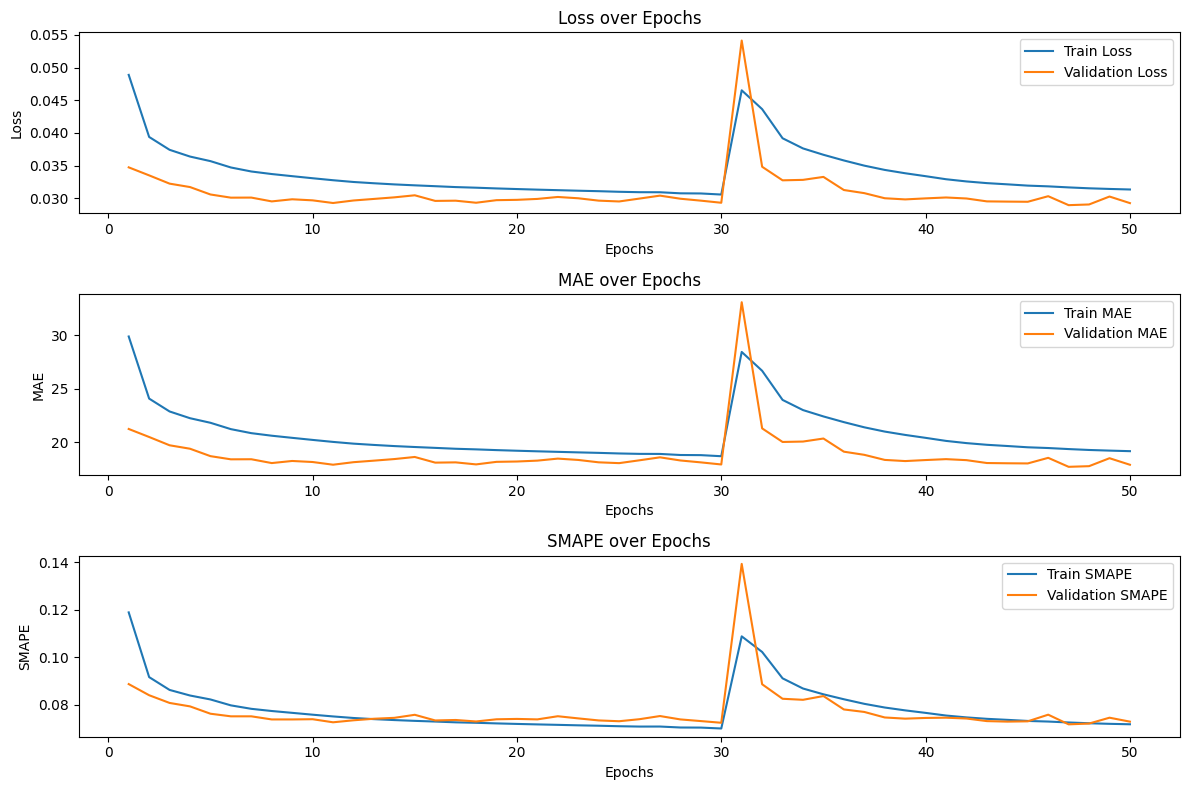

In [14]:
lstm_model = LSTM(
    c_in= 1, #entre que dim 1 car que 1 seul feature
    c_out= FUTURE_WINDOW,
    hidden_size= 64,
    n_layers= 1,
)

print(lstm_model)
print(f"  Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

outputs = train_model(lstm_model, train_loader, validation_loader, num_epochs=50, lr=0.0005, model_name='lstm_model', device=device)
print_curves(outputs)

Test MAE: 16.5332 | Test SMAPE: 0.0723 | Test MASE: 0.9479


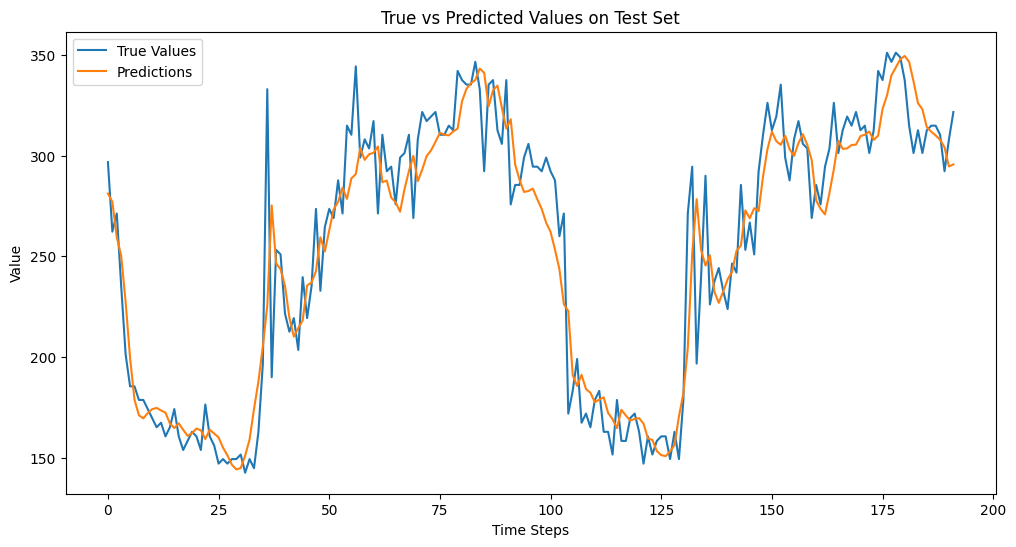

(16.533228, 0.07225384563207626, 0.9478741021646933)

In [16]:
test_model(lstm_model, test_loader, device=device, best=True, limit=2)

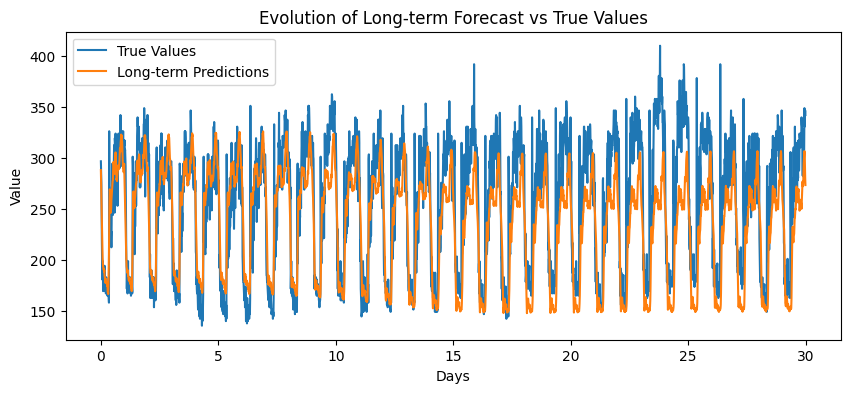

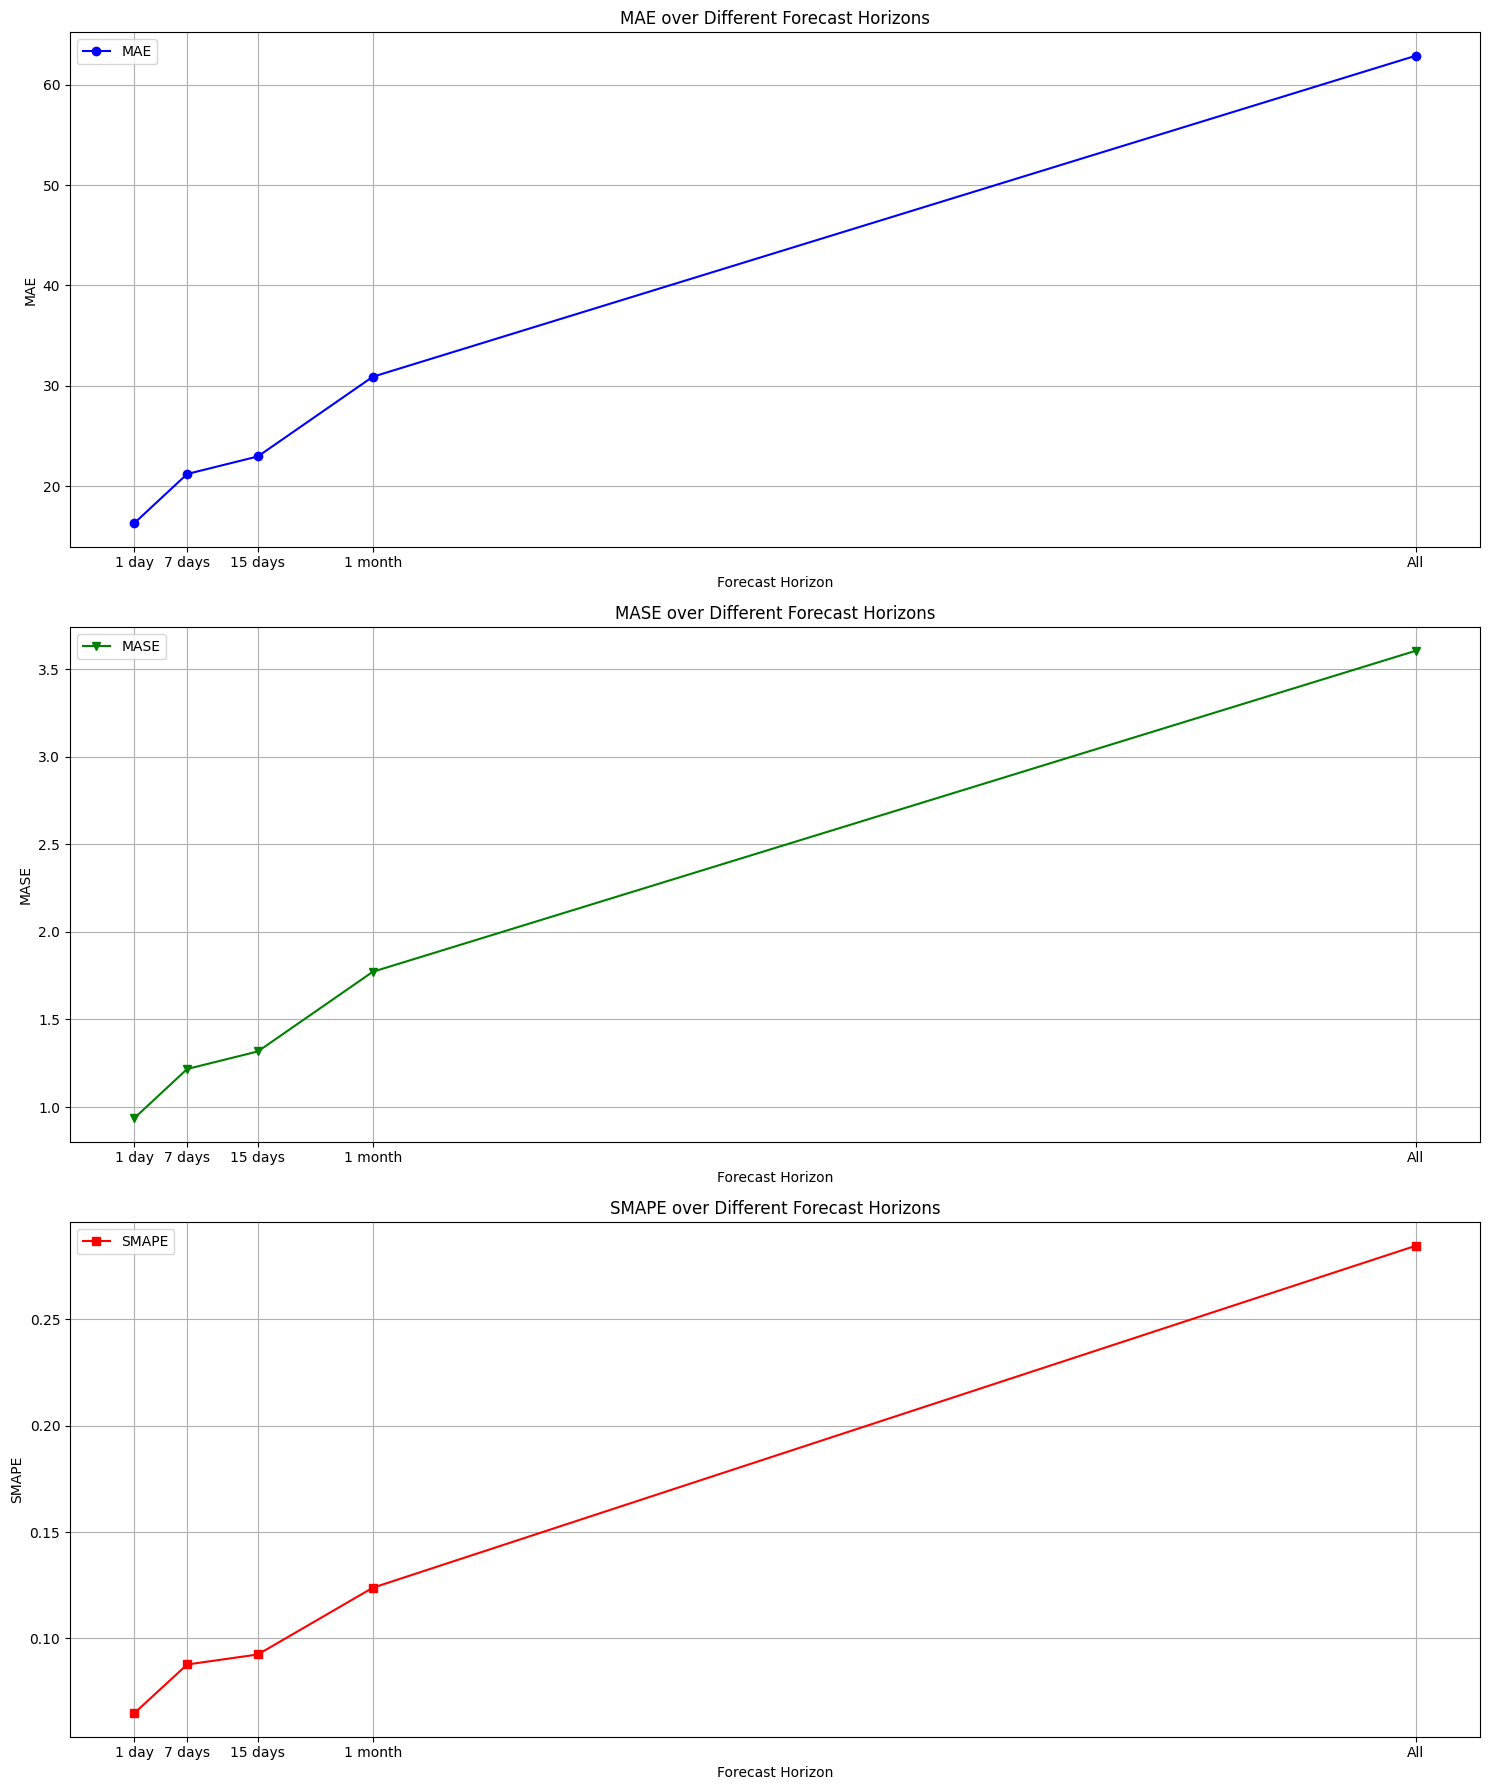

In [46]:
preds = long_term_forecast(lstm_model, validation_data_scaled, test_data_scaled, device=device, limit=30)

long_term_metric(preds, test_data['MT_292'].values, save_name="lstm_long_term_metrics.csv")


### RNN

RNN(
  (rnn): RNN(1, 12, batch_first=True)
  (dropout): Identity()
  (fc): Linear(in_features=12, out_features=96, bias=True)
)
  Parameters: 1,428
Epoch [1/30] | Train Loss: 0.0864 | Train MAE: 52.8187 | Train SMAPE: 0.2126 | Val Loss: 0.0707 | Val MAE: 43.2248 | Val SMAPE: 0.1811 | Val MASE: 2.4781
Epoch [2/30] | Train Loss: 0.0667 | Train MAE: 40.8054 | Train SMAPE: 0.1579 | Val Loss: 0.0561 | Val MAE: 34.2755 | Val SMAPE: 0.1442 | Val MASE: 1.9651
Epoch [3/30] | Train Loss: 0.0551 | Train MAE: 33.6616 | Train SMAPE: 0.1293 | Val Loss: 0.0476 | Val MAE: 29.1368 | Val SMAPE: 0.1202 | Val MASE: 1.6705
Epoch [4/30] | Train Loss: 0.0569 | Train MAE: 34.7552 | Train SMAPE: 0.1338 | Val Loss: 0.0834 | Val MAE: 50.9495 | Val SMAPE: 0.2107 | Val MASE: 2.9210
Epoch [5/30] | Train Loss: 0.0609 | Train MAE: 37.2043 | Train SMAPE: 0.1433 | Val Loss: 0.0688 | Val MAE: 42.0731 | Val SMAPE: 0.1737 | Val MASE: 2.4121
Epoch [6/30] | Train Loss: 0.0705 | Train MAE: 43.0756 | Train SMAPE: 0.1667 | Val

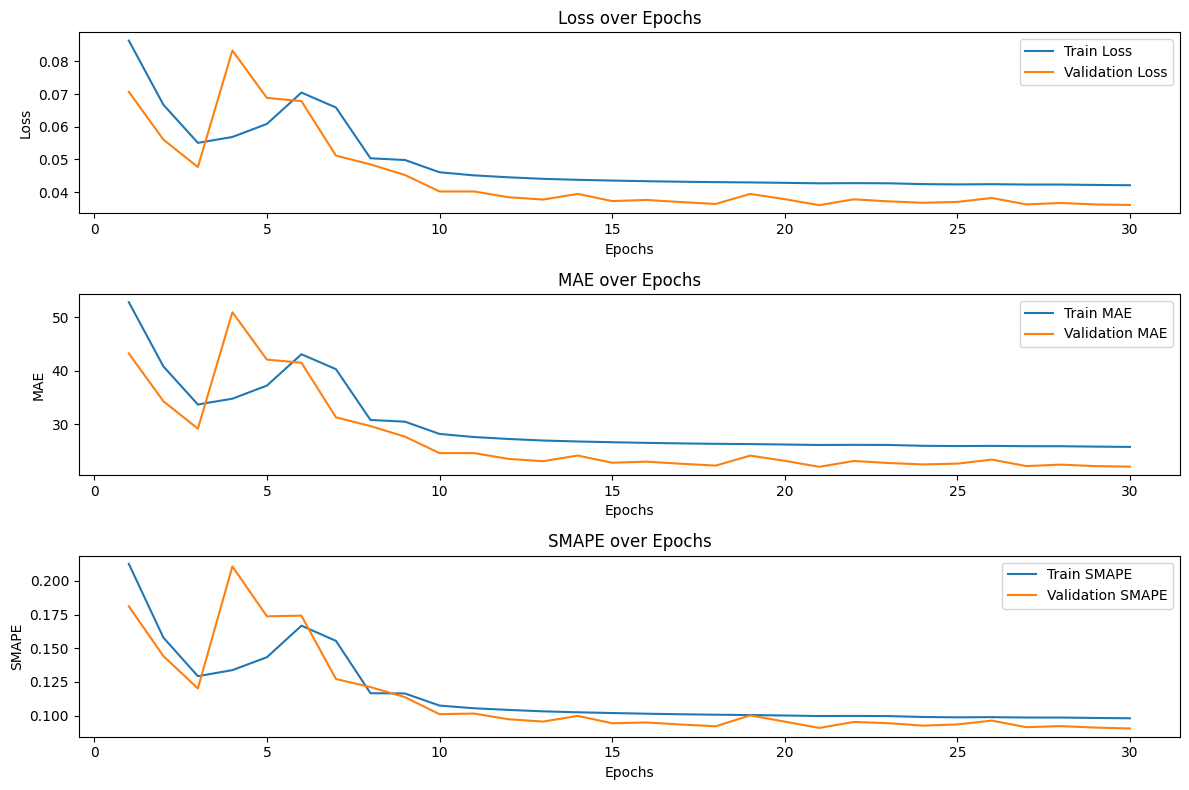

In [69]:
rnn_model = RNN(
    c_in= 1, #entre que dim 1 car que 1 seul feature
    c_out= FUTURE_WINDOW,
    hidden_size= 12,
    n_layers= 1
)

print(rnn_model)
print(f"  Parameters: {sum(p.numel() for p in rnn_model.parameters()):,}")

outputs = train_model(rnn_model, train_loader, validation_loader, num_epochs=30, lr=0.0005, model_name='rnn_model', device=device)
print_curves(outputs)

Test MAE: 30.5450 | Test SMAPE: 0.1368 | Test MASE: 1.7512


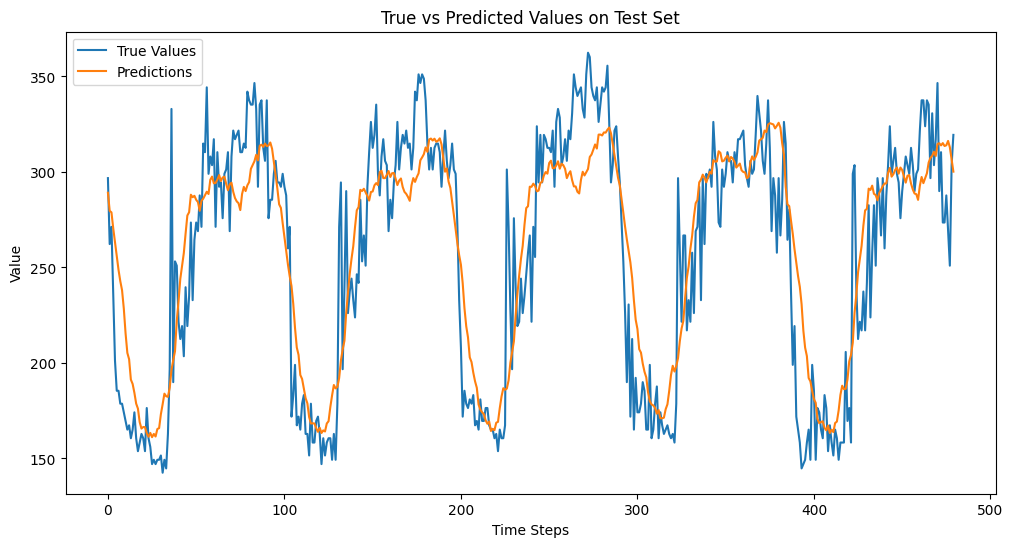

(30.545046, 0.13683395087718964, 1.7511920873730098)

In [74]:
test_model(rnn_model, test_loader, device=device, best=False, limit=5)

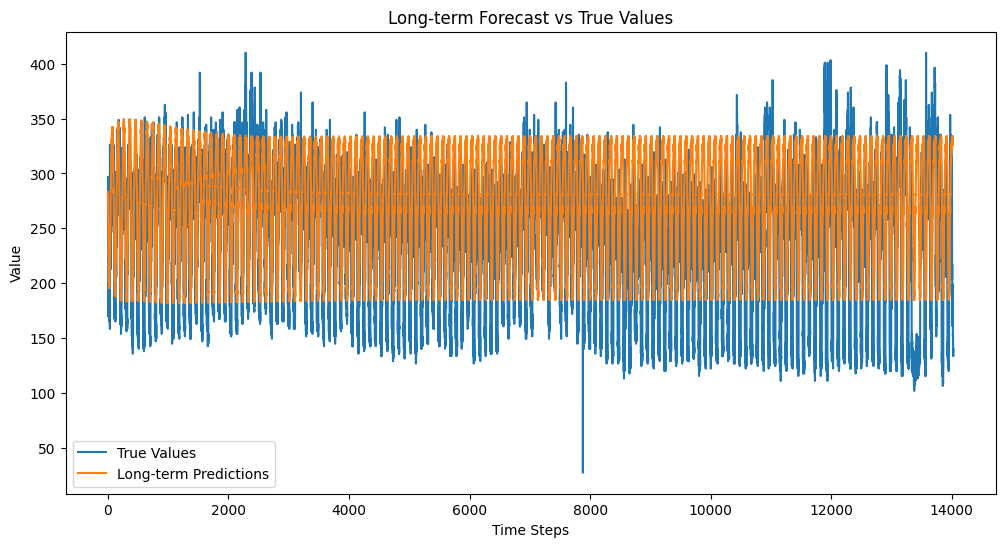

In [61]:
long_term_forecast(rnn_model, validation_data_scaled, test_data_scaled, device=device)

### Transformer

In [ ]:
tst_model = TST(
    c_in=1,
    c_out=FUTURE_WINDOW,
    seq_len=PAST_WINDOW,
    d_model=4,
    n_heads=4,
    dropout=0.1,
    n_layers=1,
)

print(tst_model)
print(f"  Parameters: {sum(p.numel() for p in tst_model.parameters()):,}")
outputs = train_model(tst_model, train_loader, validation_loader, num_epochs=30, lr=0.0001, model_name='tst_model', device=device)
print_curves(outputs)

TST(
  (W_P): Linear(in_features=1, out_features=16, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): _TSTEncoder(
    (layers): ModuleList(
      (0): _TSTEncoderLayer(
        (self_attn): _MultiHeadAttention(
          (W_Q): Linear(in_features=16, out_features=16, bias=False)
          (W_K): Linear(in_features=16, out_features=16, bias=False)
          (W_V): Linear(in_features=16, out_features=16, bias=False)
          (W_O): Linear(in_features=16, out_features=16, bias=False)
        )
        (dropout_attn): Dropout(p=0.1, inplace=False)
        (batchnorm_attn): Sequential(
          (0): Transpose(dims=1, 2).contiguous()
          (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): Transpose(dims=1, 2).contiguous()
        )
        (ff): Sequential(
          (0): Linear(in_features=16, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (

KeyboardInterrupt: 

Test MAE: 112.9129 | Test SMAPE: 0.7046 | Test MASE: 6.4735


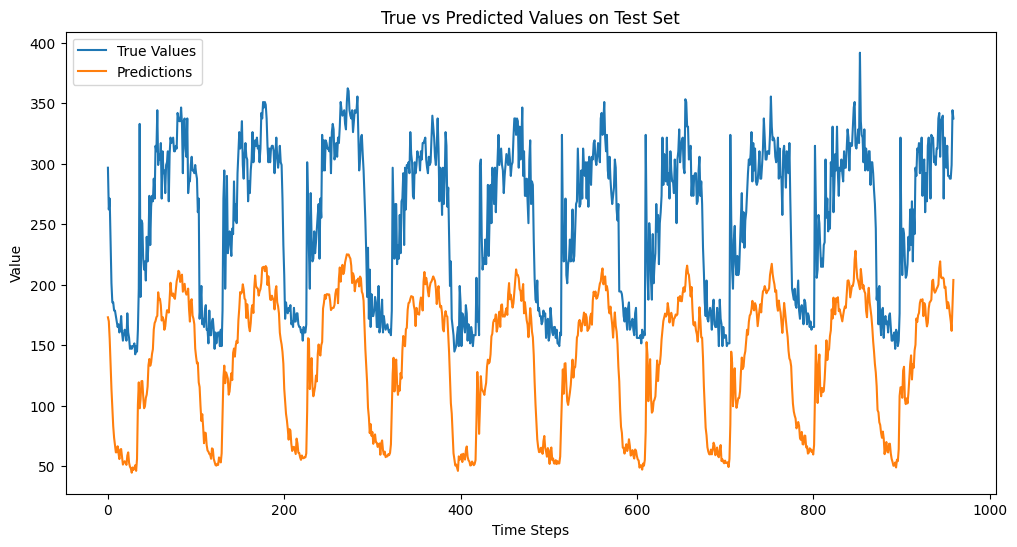

(112.91294, 0.7046194672584534, 6.473463806806516)

In [7]:
test_model(tst_model, test_loader, device=device, best=True, limit=10)

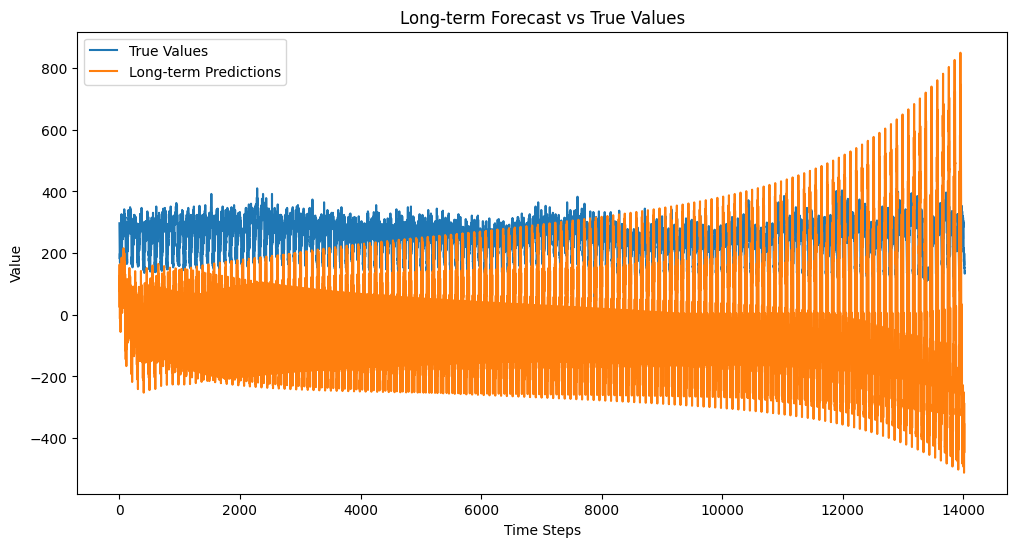

In [15]:
long_term_forecast(tst_model, validation_data_scaled, test_data_scaled, device=device)

### TSTplus

TSTPlus(
  (backbone): _TSTBackbone(
    (W_P): Sequential(
      (0): Pad1d(padding=(176, 176), value=0.0)
      (1): Conv1d(1, 12, kernel_size=(2,), stride=(2,))
    )
    (dropout): Dropout(p=0.1, inplace=False)
    (encoder): _TSTEncoder(
      (layers): ModuleList(
        (0): _TSTEncoderLayer(
          (self_attn): MultiheadAttention(
            (W_Q): Linear(in_features=12, out_features=12, bias=True)
            (W_K): Linear(in_features=12, out_features=12, bias=True)
            (W_V): Linear(in_features=12, out_features=12, bias=True)
            (sdp_attn): ScaledDotProductAttention(
              (attn_dropout): Dropout(p=0.0, inplace=False)
            )
            (to_out): Sequential(
              (0): Linear(in_features=12, out_features=12, bias=True)
              (1): Dropout(p=0.1, inplace=False)
            )
          )
          (dropout_attn): Dropout(p=0.1, inplace=False)
          (norm_attn): Sequential(
            (0): Transpose(dims=1, 2).contiguous()

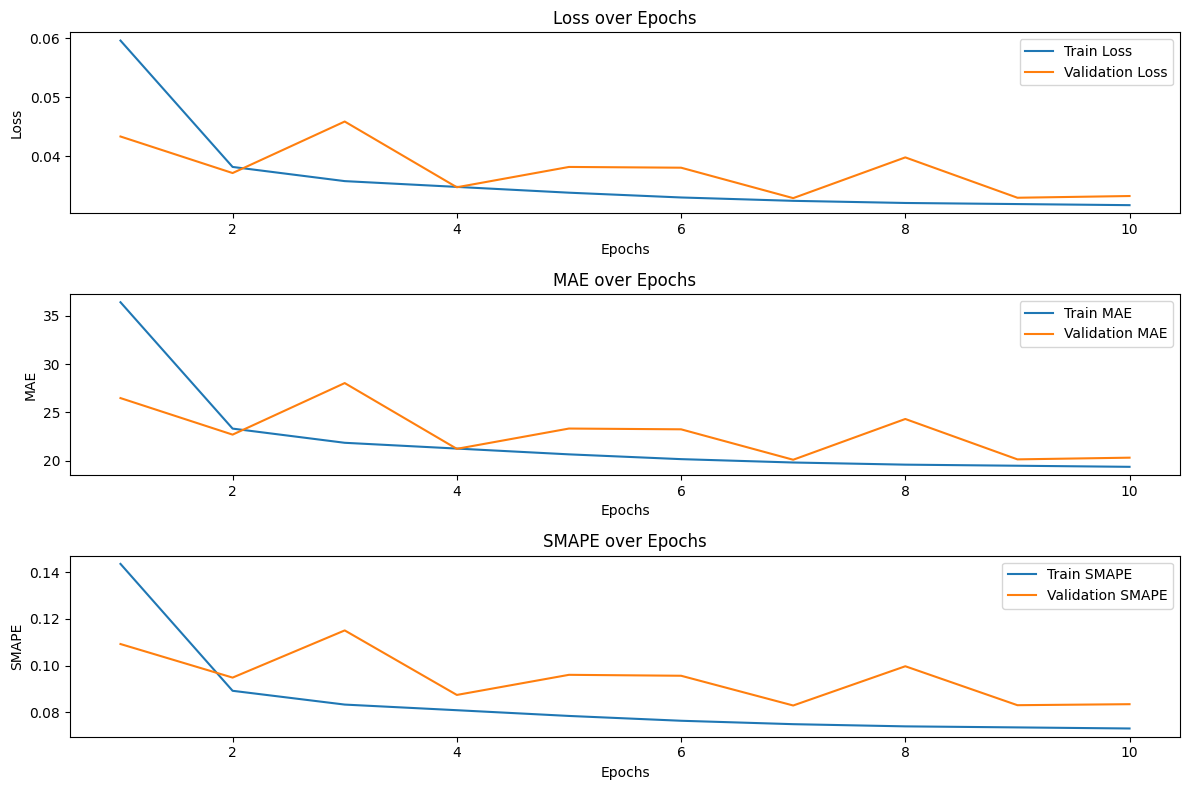

In [23]:
tstplus_model = TSTPlus(
    c_in=1,
    c_out=FUTURE_WINDOW,
    seq_len=PAST_WINDOW,
    d_model=12,
    n_heads=12,
    dropout=0.1,
    n_layers=1,
)

print(tstplus_model)
print(f"  Parameters: {sum(p.numel() for p in tstplus_model.parameters()):,}")
outputs = train_model(tstplus_model, train_loader, validation_loader, num_epochs=10, lr=0.0001, model_name='tstplus_model_12', device=device)
print_curves(outputs)

Test MAE: 14.5535 | Test SMAPE: 0.0631 | Test MASE: 0.8344


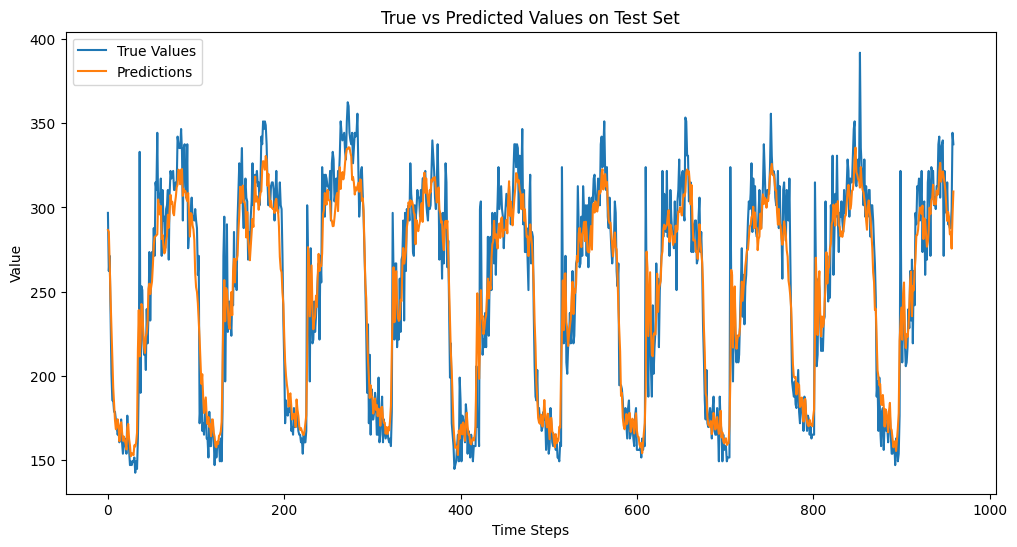

(14.553519, 0.06314612179994583, 0.8343745128146)

In [39]:
test_model(tstplus_model, test_loader, device=device, best=True, limit=10)

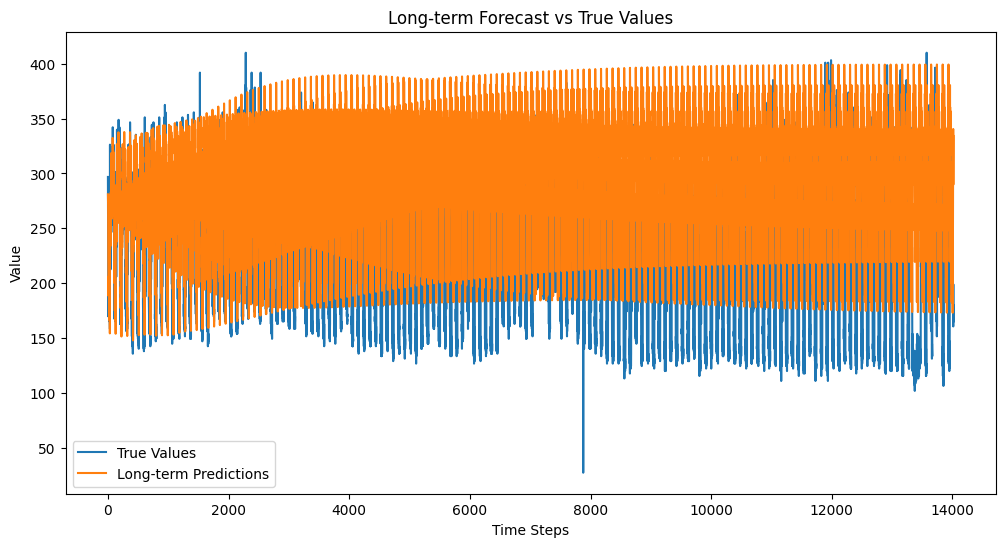

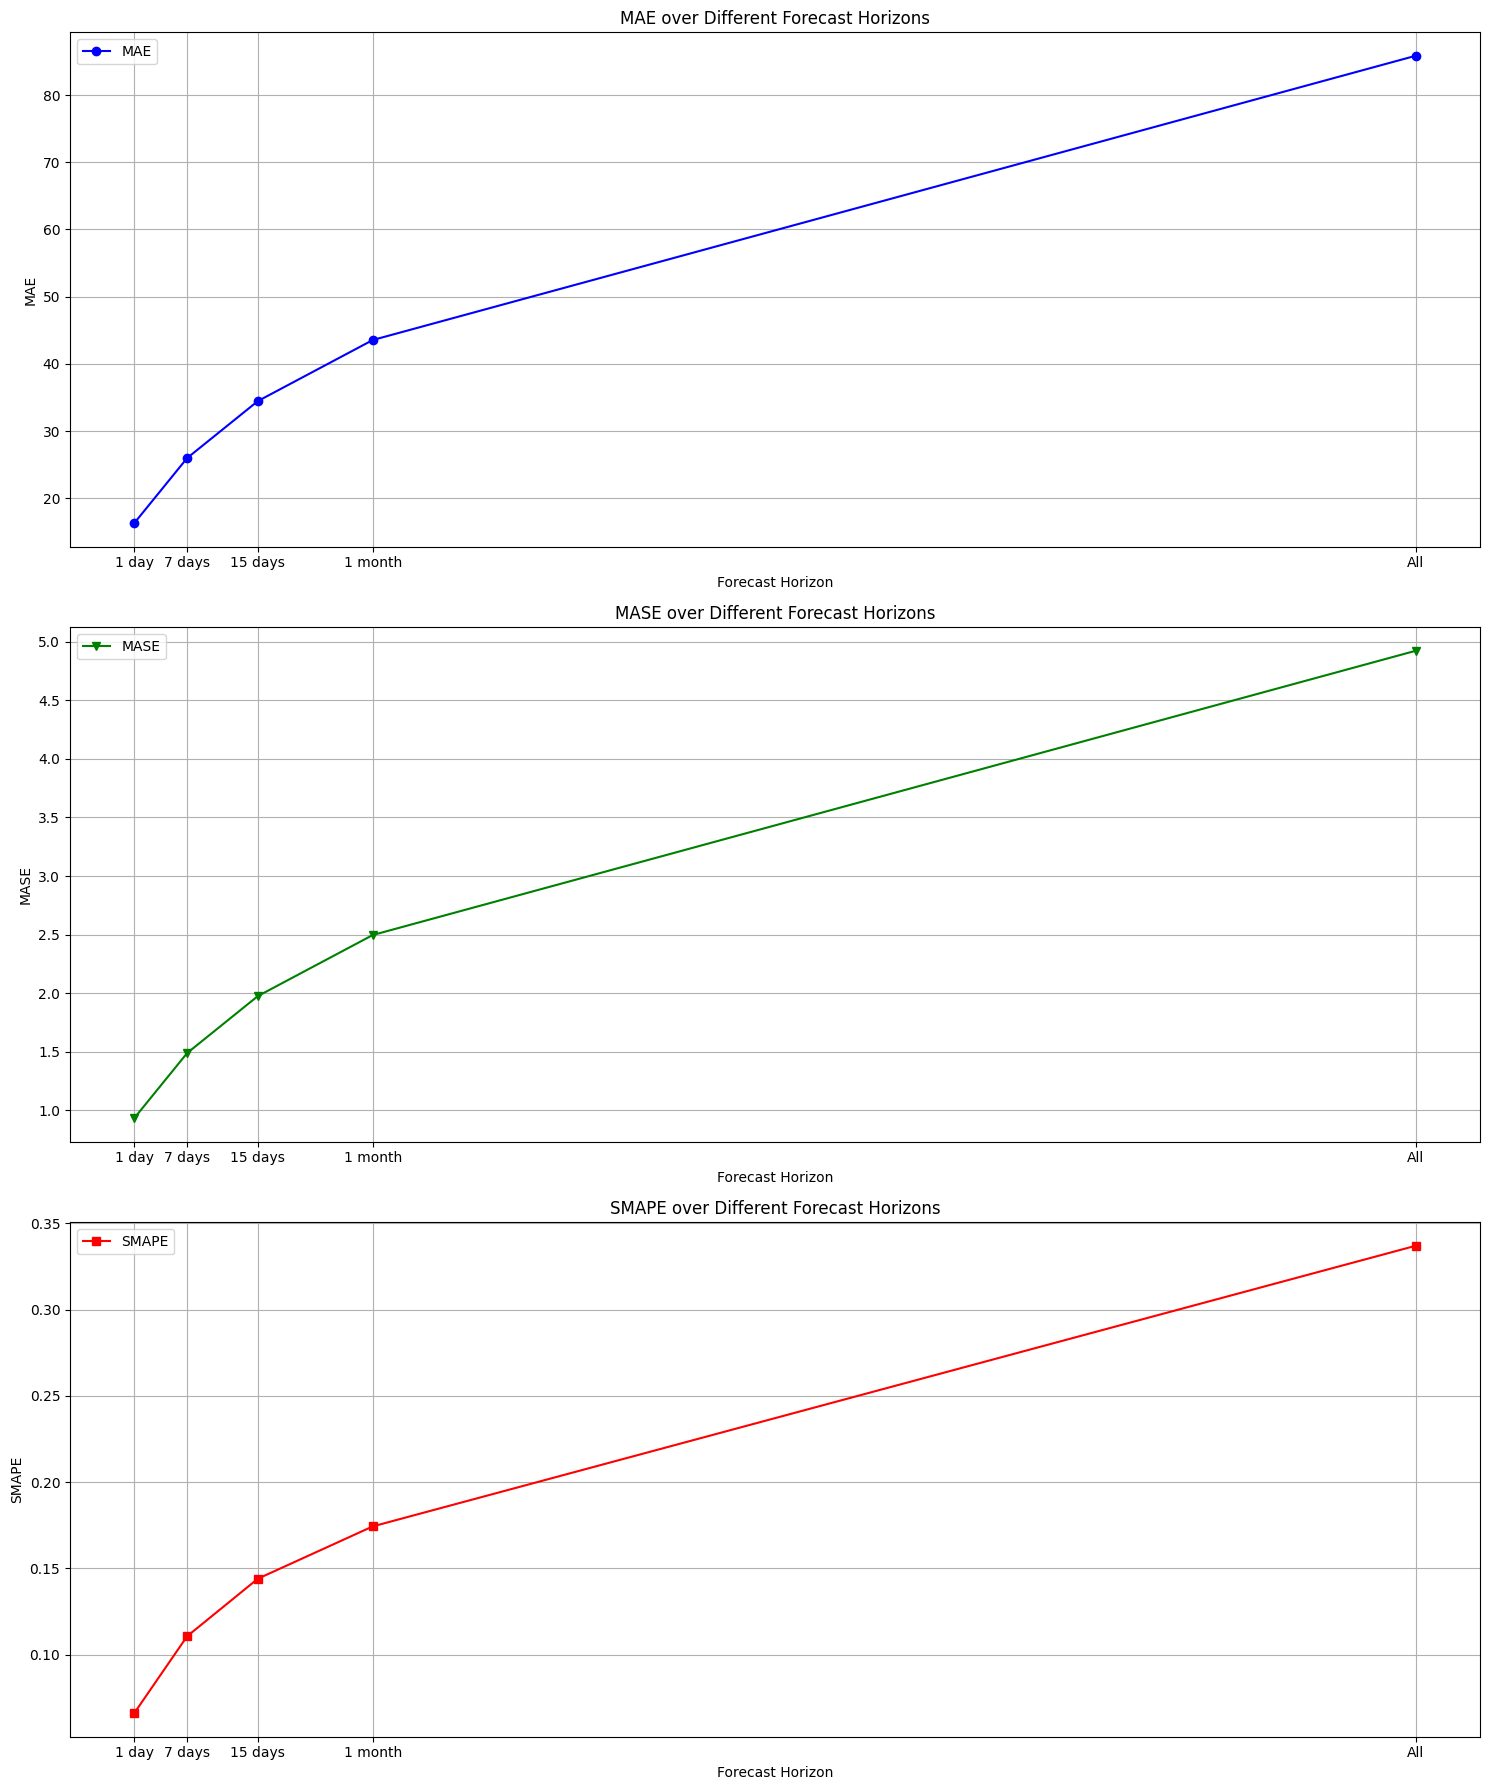

In [25]:
preds = long_term_forecast(tstplus_model, validation_data_scaled, test_data_scaled, device=device)
long_term_metric(preds, test_data['MT_292'].values, save_name="tstplus_long_term_metrics.csv")

------

Faire le graph de comparaison pour le long term forecasting

0    66.731009
1    72.454419
2    71.626950
3    68.440549
4    87.172112
Name: MAE, dtype: float64


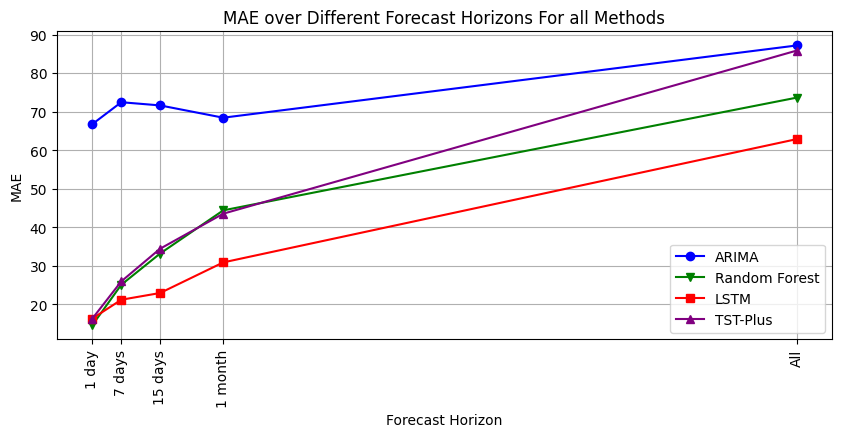

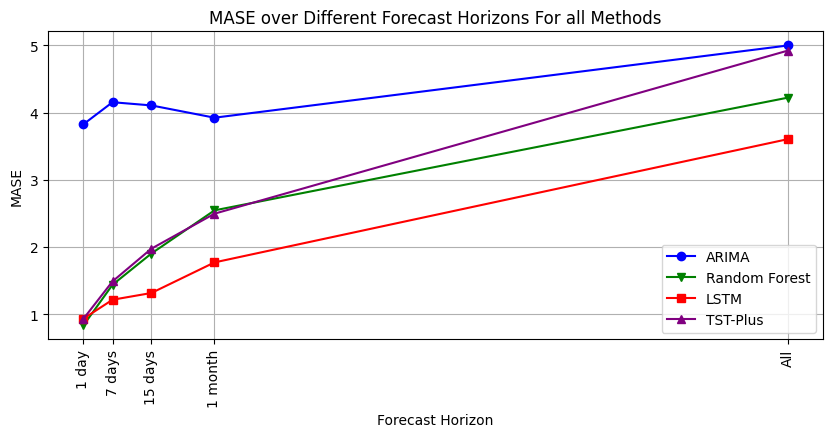

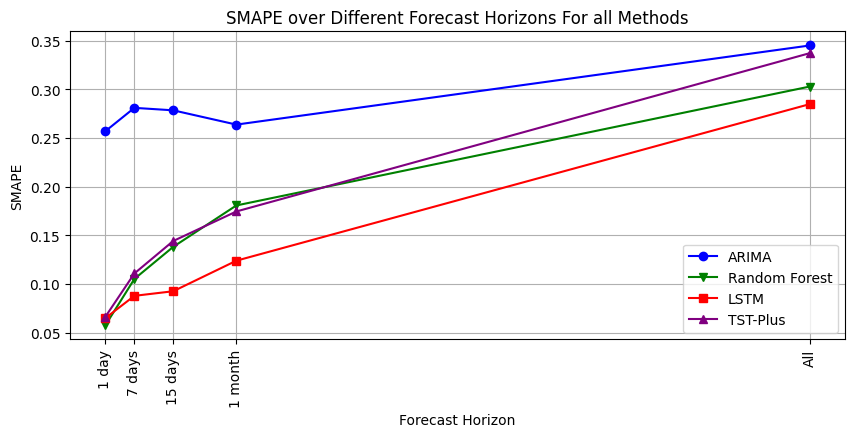

In [38]:
file_names = ["arima_long_term_metrics.csv", "rf_long_term_metrics.csv" ,'lstm_long_term_metrics.csv', 'tstplus_long_term_metrics.csv']

method_names = ['ARIMA', 'Random Forest', 'LSTM', 'TST-Plus']

metrics_dfs = [pd.read_csv(fname) for fname in file_names]

print(metrics_dfs[0]['MAE'])


colors = ['blue', 'green', 'red', 'purple']
markers = ['o', 'v', 's', '^']

x = metrics_dfs[0]['Horizon'].values

plt.figure(figsize=(10, 4))

for i, df in enumerate(metrics_dfs):
    plt.plot(x, df['MAE'], label=method_names[i], marker=markers[i], color=colors[i])
plt.xticks(x, ['1 day', '7 days', '15 days', '1 month', 'All'], rotation=90)
plt.xlabel('Forecast Horizon')
plt.ylabel('MAE')
plt.title('MAE over Different Forecast Horizons For all Methods')
plt.legend()
plt.grid()
plt.show()



plt.figure(figsize=(10, 4))

for i, df in enumerate(metrics_dfs):
    plt.plot(x, df['MASE'], label=method_names[i], marker=markers[i], color=colors[i])
plt.xticks(x, ['1 day', '7 days', '15 days', '1 month', 'All'], rotation=90)
plt.xlabel('Forecast Horizon')
plt.ylabel('MASE')
plt.title('MASE over Different Forecast Horizons For all Methods')
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(10, 4))

for i, df in enumerate(metrics_dfs):
    plt.plot(x, df['SMAPE'], label=method_names[i], marker=markers[i], color=colors[i])
plt.xticks(x, ['1 day', '7 days', '15 days', '1 month', 'All'], rotation=90)
plt.xlabel('Forecast Horizon')
plt.ylabel('SMAPE')
plt.title('SMAPE over Different Forecast Horizons For all Methods')
plt.legend()
plt.grid()
plt.show()
